# 01 資料預處理
本筆記本負責資料的載入、基本品質檢查（缺失值與重複值）、變數分類、特徵工程（時間特徵提取）、離群值處理（Winsorization 截尾）以及特徵變換（Log 轉換與視覺化驗證）。

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.family'] = ['Microsoft JhengHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 添加專案根目錄到 Python 路徑
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 匯入資料載入系統
from src.data_loader import load_data, DataLoader, ConfigLoader

# 載入配置
config = ConfigLoader.load_config(project_root / "config.yaml")
loader = DataLoader(config)

print("✅ 環境初始化完成")

2026-05-18 17:14:02,119 - src.data_loader - INFO - ✅ 設定檔已載入: c:\Users\fromn\OneDrive\Desktop\dataMiningCourse\dataMining\config.yaml


✅ 環境初始化完成


In [2]:
# 載入原始資料（若本地無資料則會自動嘗試從 Kaggle 下載）
df = load_data()
print(f"原始資料形狀: {df.shape}")
display(df.head())

# 基本統計摘要
print("\n數值欄位摘要:")
display(df.describe())

print("\n所有欄位摘要:")
display(df.describe(include='all').T)

2026-05-18 17:14:02,143 - src.data_loader - INFO - ✅ 設定檔已載入: c:\Users\fromn\OneDrive\Desktop\dataMiningCourse\dataMining\config.yaml
2026-05-18 17:14:02,145 - src.data_loader - INFO - ✅ 優先使用專案本地資料: c:\Users\fromn\OneDrive\Desktop\dataMiningCourse\dataMining\data\raw\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv
2026-05-18 17:14:02,145 - src.data_loader - INFO - 📖 讀取資料檔案: c:\Users\fromn\OneDrive\Desktop\dataMiningCourse\dataMining\data\raw\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv
2026-05-18 17:14:02,189 - src.data_loader - INFO - ✅ 資料已載入 | 形狀: (10345, 17)


原始資料形狀: (10345, 17)


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk



數值欄位摘要:


,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000



所有欄位摘要:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10345.0,NaN,NaN,NaN,5173.0,2986.488601,1.0,2587.0,5173.0,7759.0,10345.0
age,10345.0,NaN,NaN,NaN,38.559884,12.131789,18.0,28.0,39.0,49.0,59.0
employment_type,10345,4,Salaried,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,10345.0,NaN,NaN,NaN,35053.381898,27084.517277,5000.0,12207.02,23800.52,55276.93,145767.12
credit_score,10345.0,NaN,NaN,NaN,448.176124,136.518332,300.0,332.0,403.0,547.0,850.0
purchase_amount,10345.0,NaN,NaN,NaN,3979.402721,1500.828483,100.0,2990.72,5000.0,5000.0,5000.0
product_category,10345,5,Fashion,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bnpl_installments,10345.0,NaN,NaN,NaN,7.477525,3.362867,3.0,3.0,9.0,9.0,12.0
repayment_delay_days,10345.0,NaN,NaN,NaN,8.742774,6.781849,0.0,2.0,9.0,14.0,33.0
missed_payments,10345.0,NaN,NaN,NaN,1.01595,0.996726,0.0,0.0,1.0,2.0,7.0


## 3. 變數分類 (根據統計學型態)
將變數分為類別型 (Categorical)、順序型 (Ordinal)、區間型 (Interval) 與比率型 (Ratio)。

In [5]:
data_types = {
    'Categorical': ['employment_type', 'product_category', 'location', 'default_flag'],
    'Ordinal': ['customer_segment'],
    'Interval': ['credit_score'],
    'Ratio': ['age', 'monthly_income', 'purchase_amount', 'bnpl_installments', 
              'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 
              'debt_to_income_ratio', 'risk_score']  
}

process_ways = {
    'One-Hot': ['employment_type', 'product_category', 'location'],
    'Ordinal': ['customer_segment'],
    'Log': ['credit_score', 'age', 'monthly_income', 'purchase_amount','repayment_delay_days', 'app_usage_frequency', 'debt_to_income_ratio'],
    'Z-Score': ['risk_score'],
    'winsor_columns': ['monthly_income', 'debt_to_income_ratio', 'risk_score', 'repayment_delay_days', 'missed_payments'],
    'No-Process':['bnpl_installments', 'default_flag']  
}
print("✅ 變數分類完成")

✅ 變數分類完成


## 4. 離群值處理 (Winsorization 截尾)\n
依照 cluster_guide，對指定欄位進行 Winsorization（上下界各 2.5% 截尾），降低極端值對分群距離的影響。

In [6]:
def handle_outliers_winsorization(data, columns, lower_quantile=0.025, upper_quantile=0.975):
    df_clean = data.copy()
    
    print(f"{'欄位名稱':<20} | {'離群值數量':<6} | {'邊界範圍':<20}")
    print("-" * 55)

    for idx, col in enumerate(columns):
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        num_outliers = outliers_mask.sum()
        
        print(f"{col:20} | {num_outliers:10} | [{lower_bound:8.2f}, {upper_bound:8.2f}]")

    return df_clean

# 依據 cluster_guide 指定需做截尾的欄位
winsor_columns = process_ways['winsor_columns']

df = handle_outliers_winsorization(df, winsor_columns, lower_quantile=0.025, upper_quantile=0.975)

欄位名稱                 | 離群值數量  | 邊界範圍                
-------------------------------------------------------
monthly_income       |         25 | [-52397.85, 119881.80]
debt_to_income_ratio |         57 | [   -0.20,     0.55]
risk_score           |         31 | [    7.80,   396.60]
repayment_delay_days |          1 | [  -16.00,    32.00]
missed_payments      |          8 | [   -3.00,     5.00]


## 5. Log 轉換與視覺化對比
針對02_EDA直方圖呈現偏態分佈的欄位進行 Log 轉換，並繪製 **直方圖 (Histogram)** 與 **QQ 圖 (QQ Plot)**。

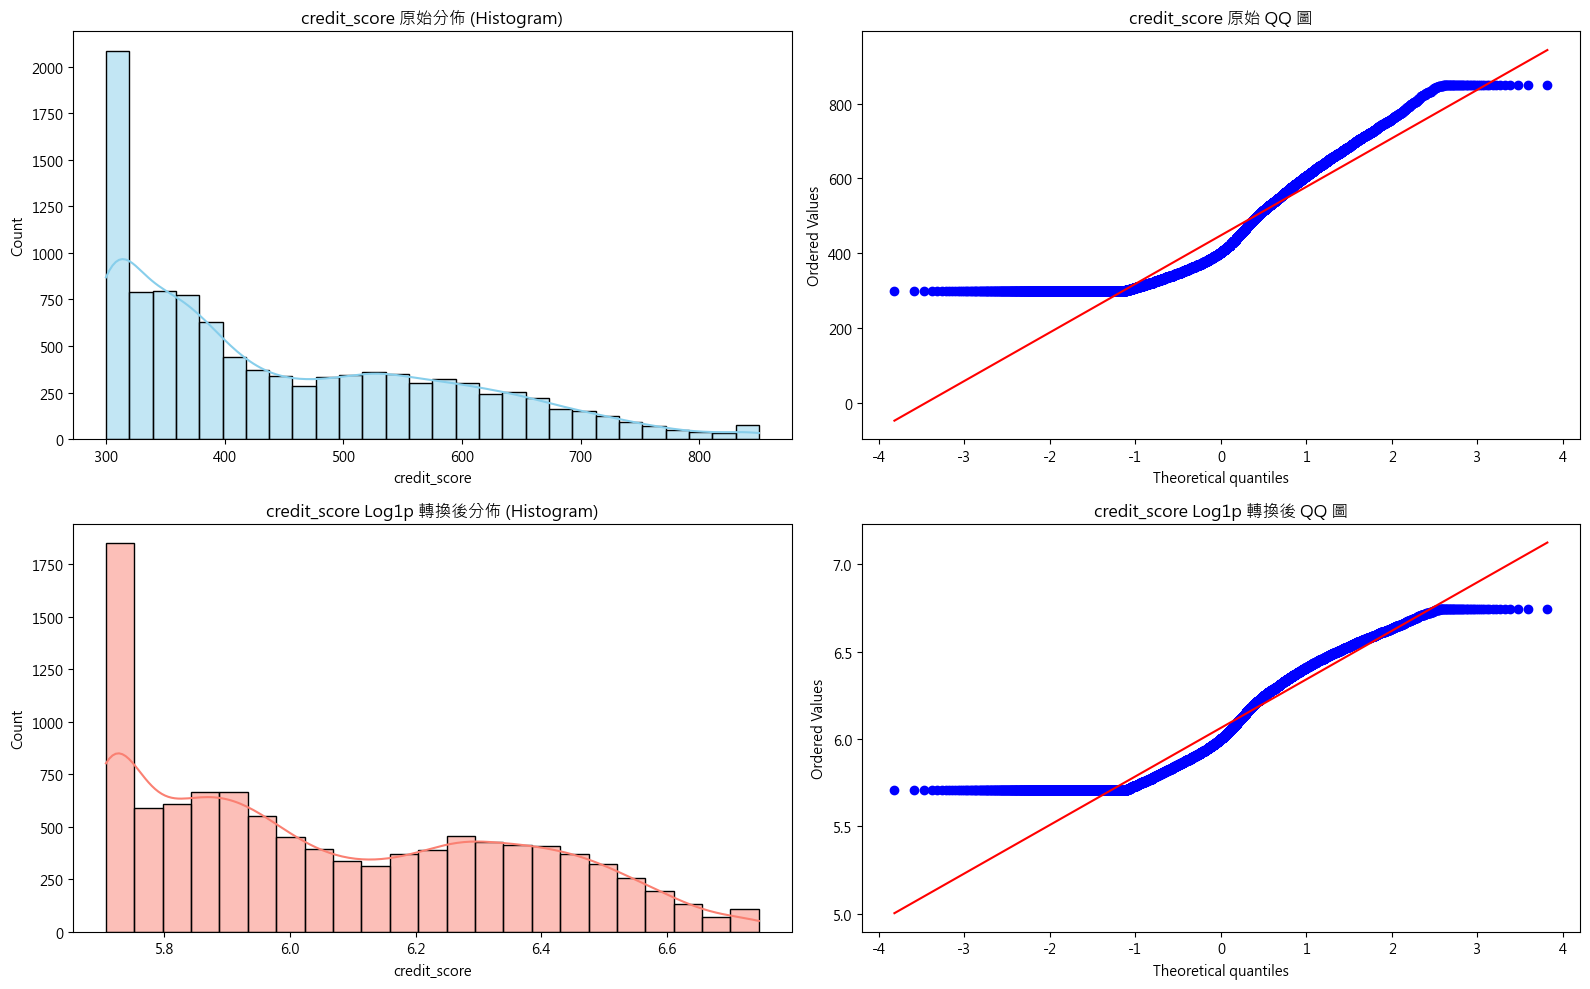

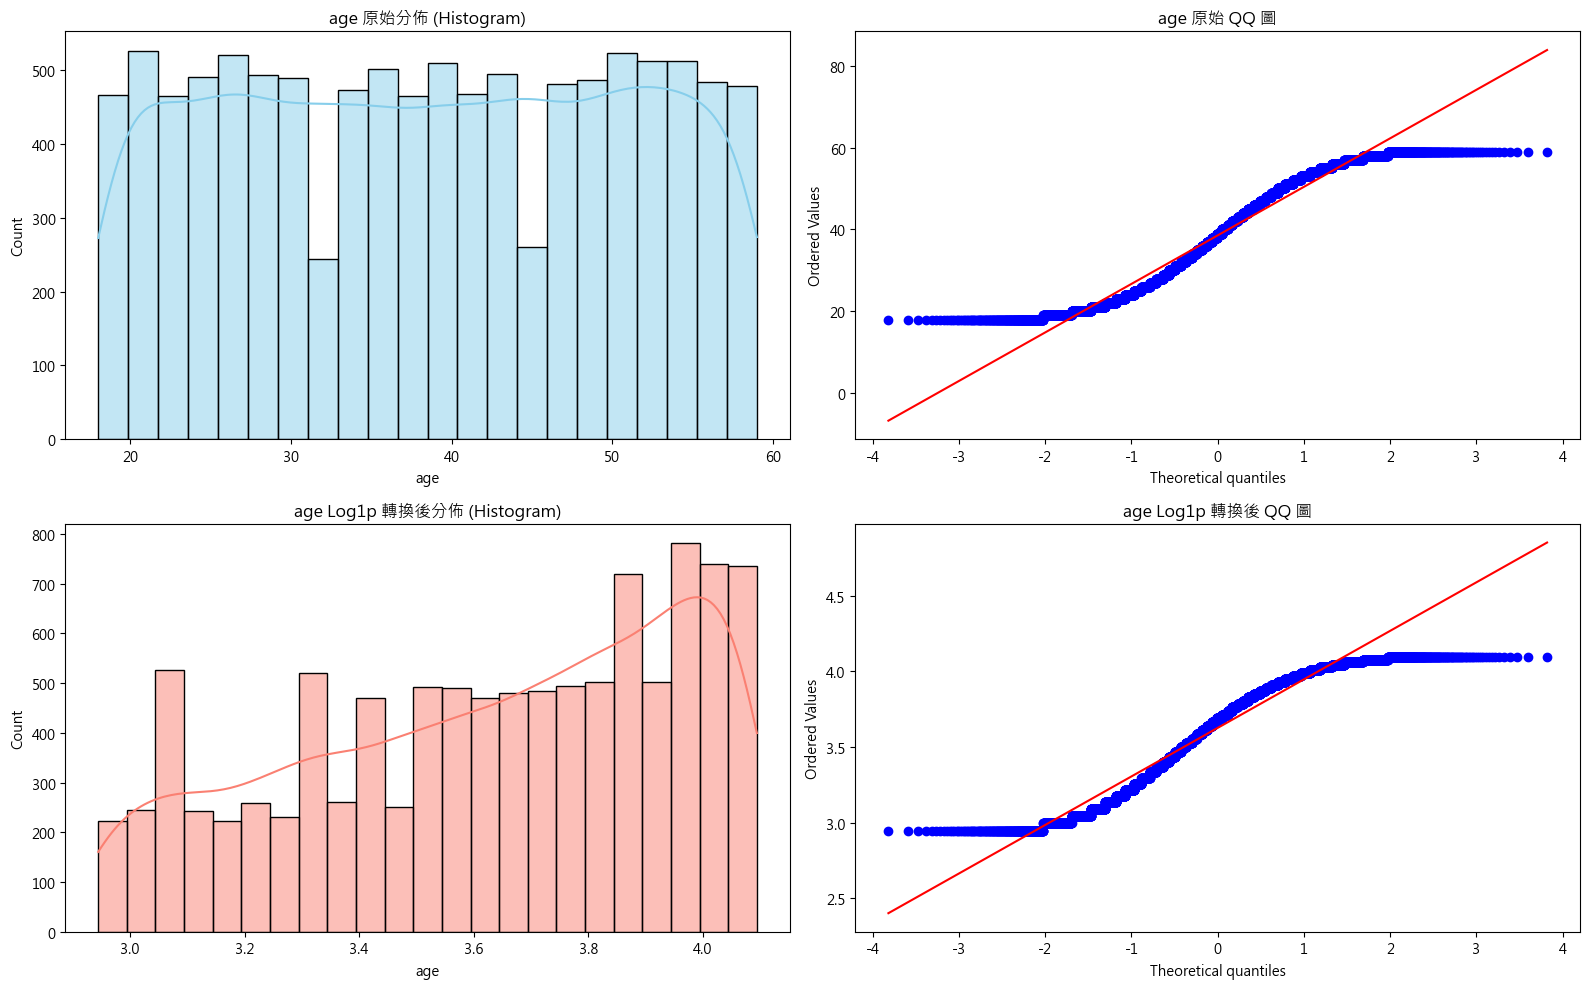

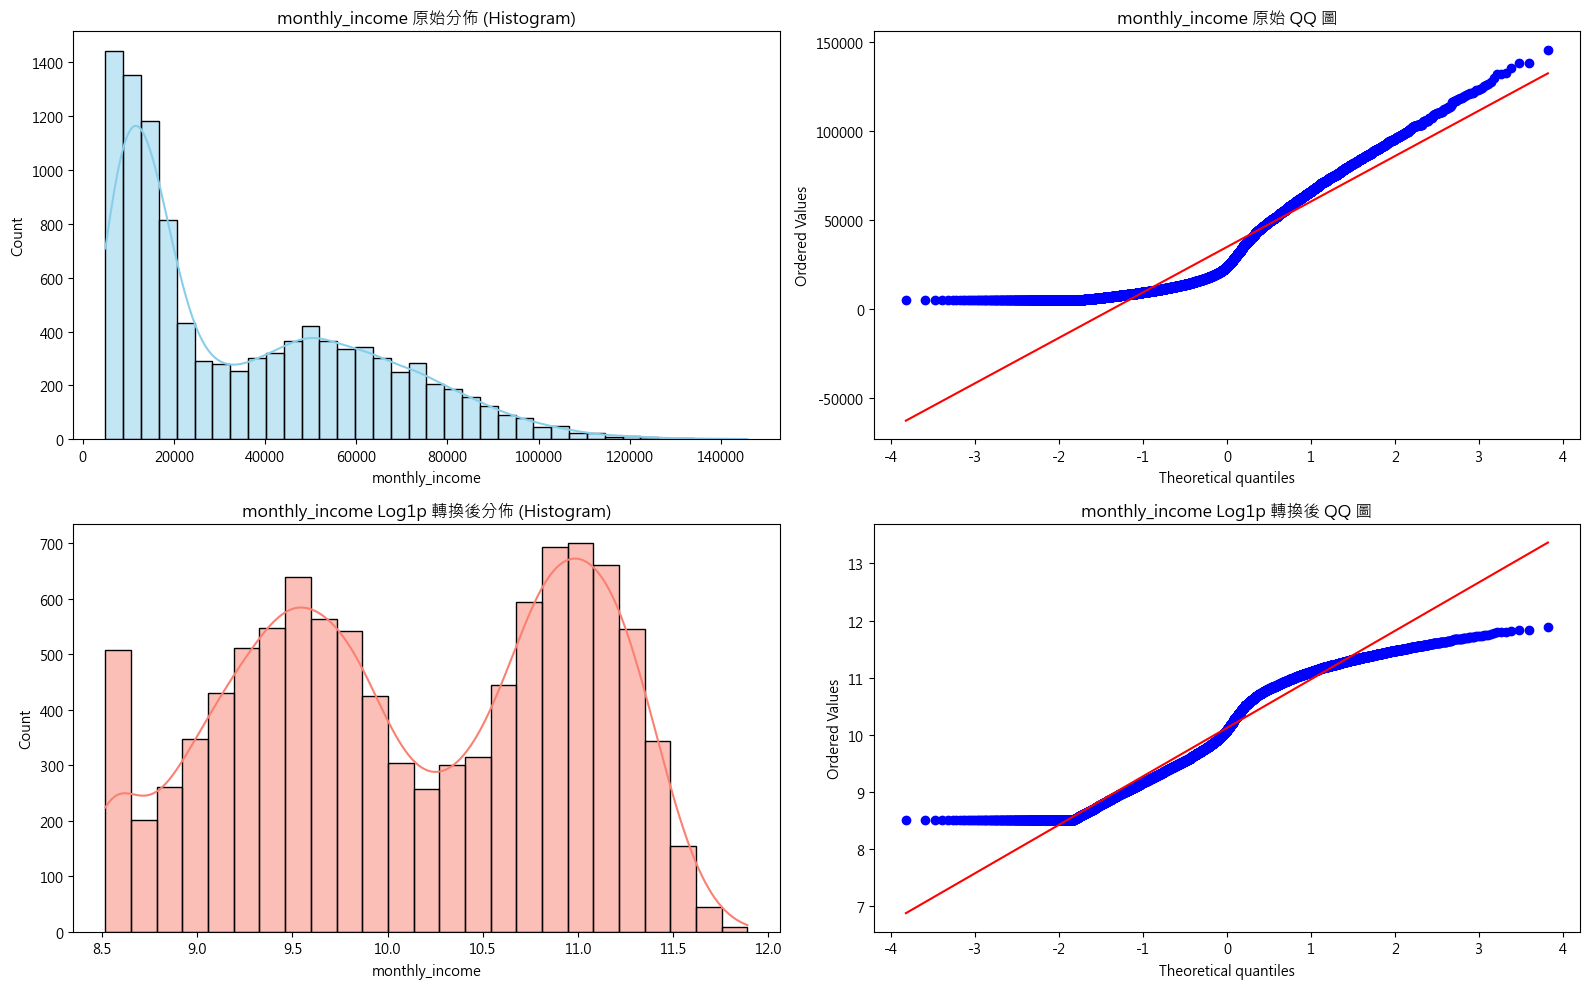

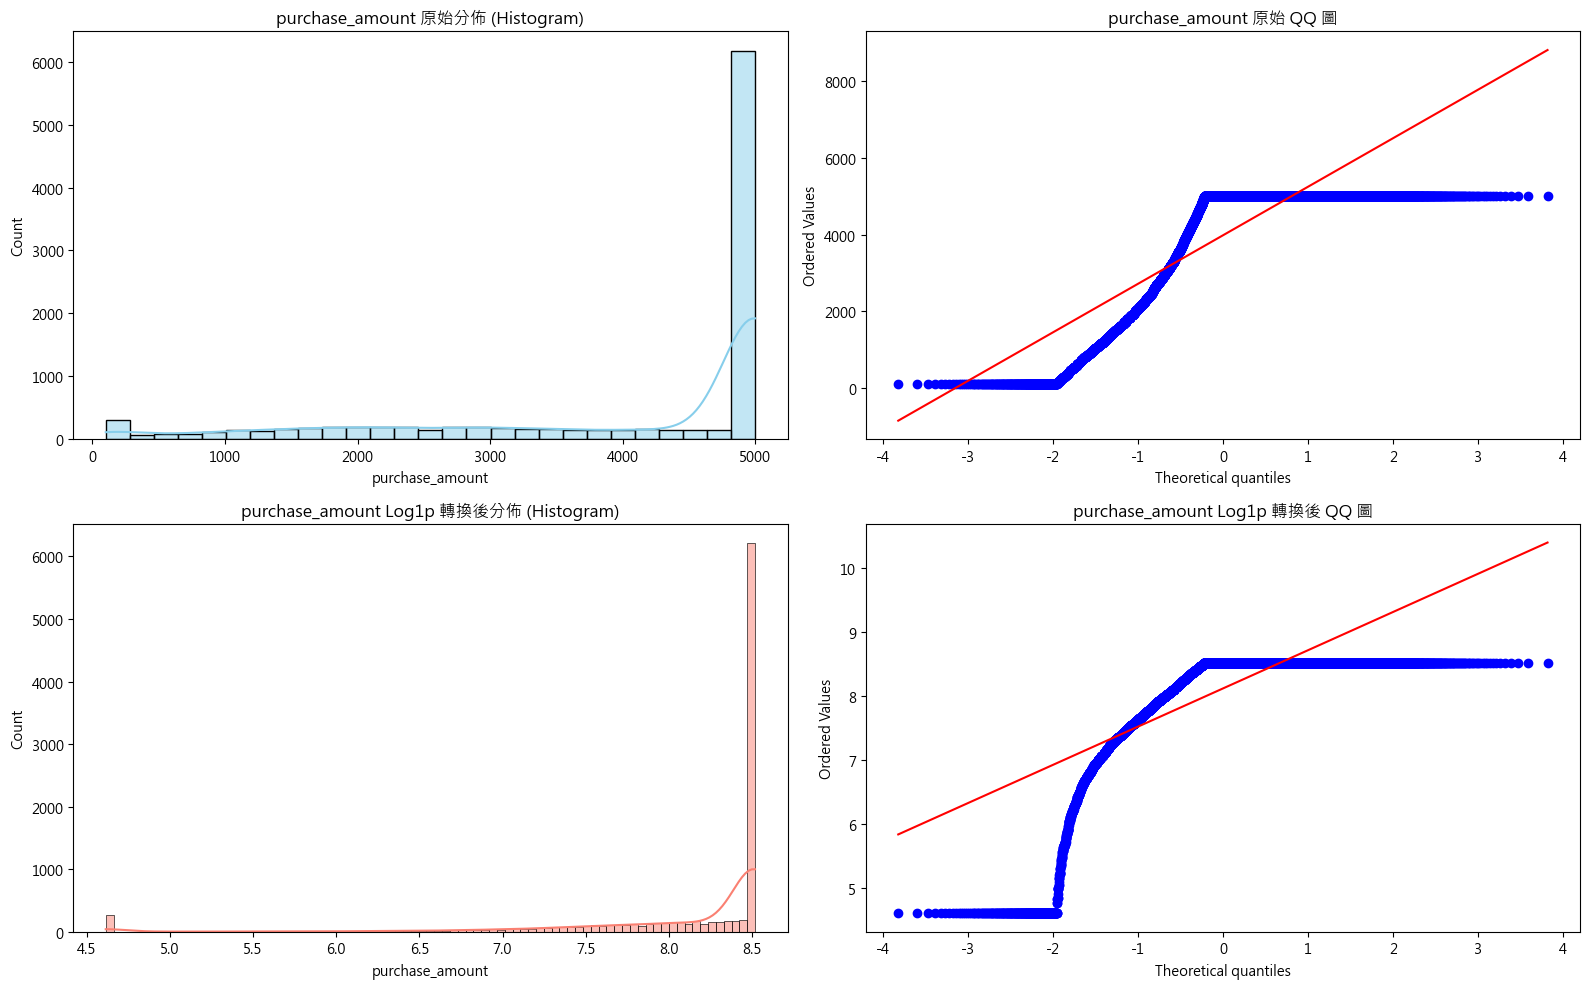

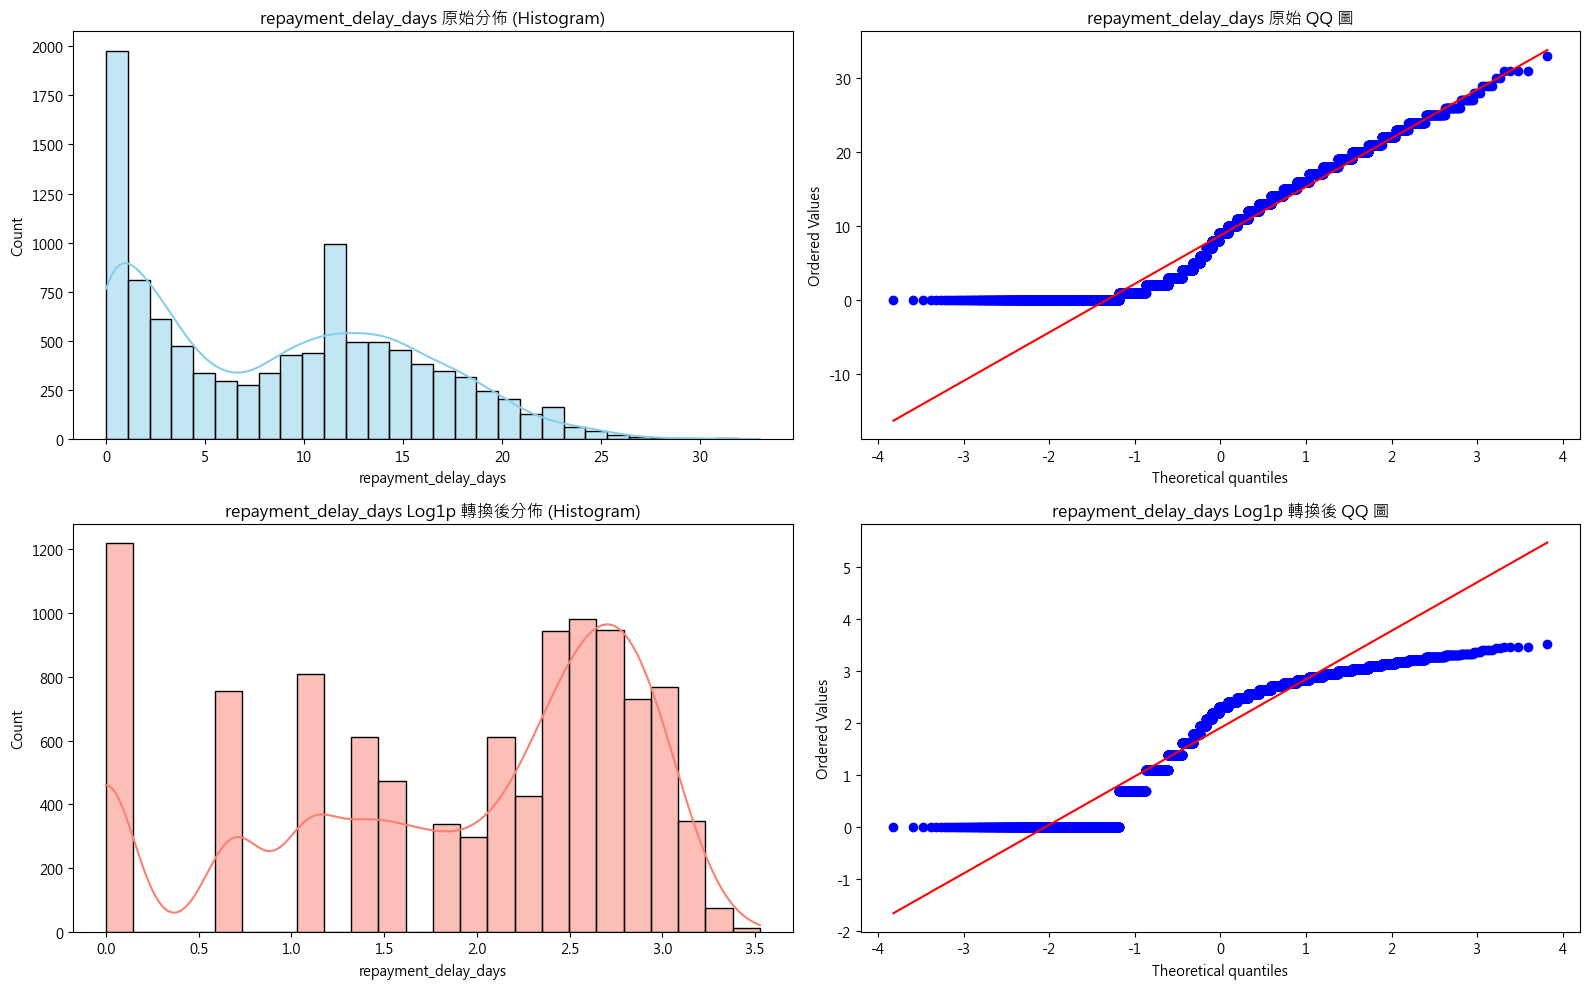

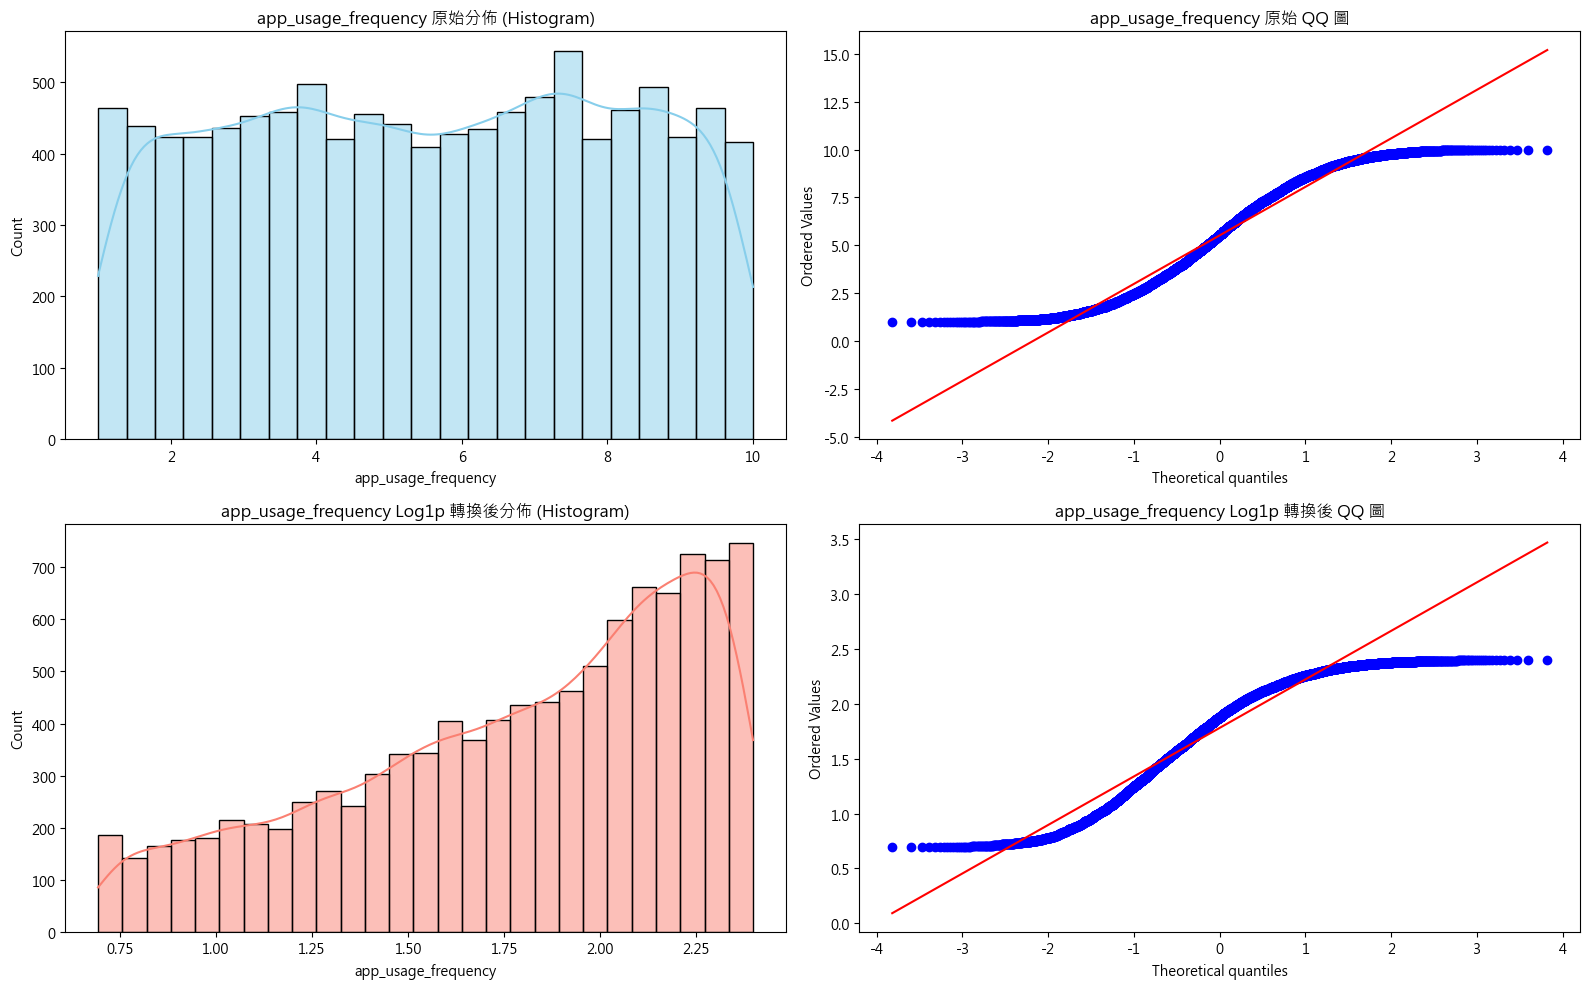

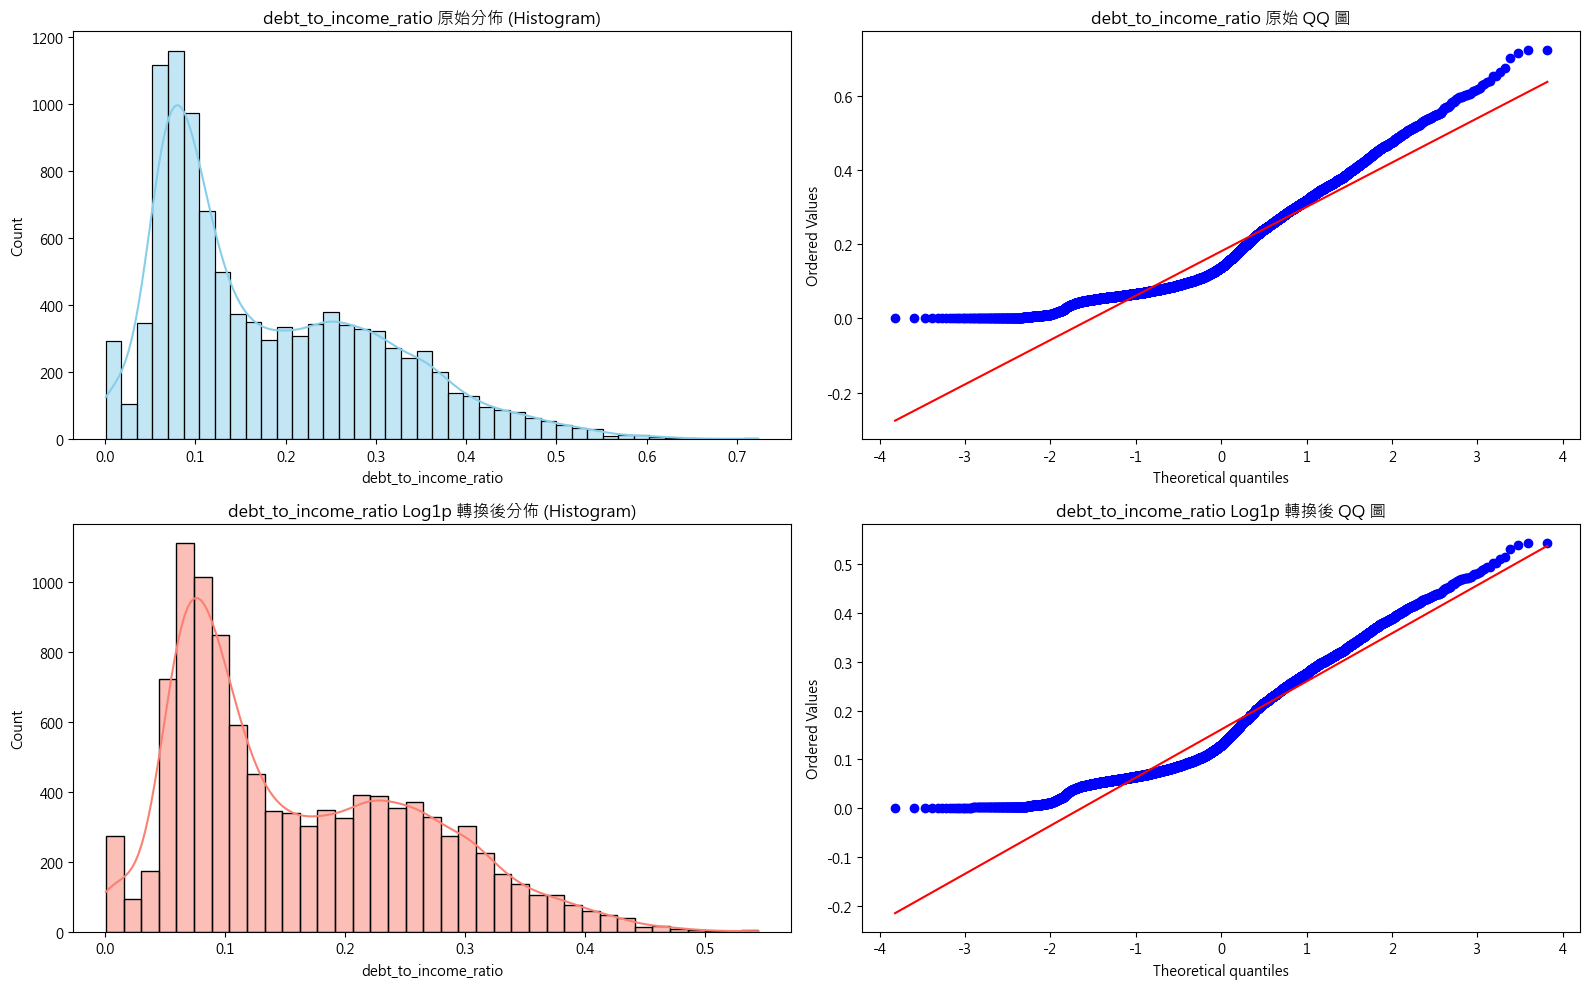

In [7]:
def plot_log_comparison(data, column):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    transform_name = "Log1p"
    
    # 轉換前 - 直方圖
    sns.histplot(data[column], kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title(f'{column} 原始分佈 (Histogram)')
    
    # 轉換前 - QQ 圖
    stats.probplot(data[column], dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title(f'{column} 原始 QQ 圖')
    
    # 執行轉換
    transformed = np.log1p(data[column])
    new_col_name = f"{column}_{transform_name.lower()}"
    data[new_col_name] = transformed
    
    # 轉換後 - 直方圖
    sns.histplot(transformed, kde=True, ax=axes[1, 0], color='salmon')
    axes[1, 0].set_title(f'{column} {transform_name} 轉換後分佈 (Histogram)')
    
    # 轉換後 - QQ 圖
    stats.probplot(transformed, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f'{column} {transform_name} 轉換後 QQ 圖')
    
    plt.tight_layout()
    plt.show()
    data = data.drop(columns=[column])
    return data

# 僅針對明顯右偏的變數進行 Log 轉換
# risk_score 已接近正態分佈，無需轉換
log_targets = process_ways['Log']

for col in log_targets:
    df = plot_log_comparison(df, col)

## 6. One-Hot&Ordinal Encoding


In [8]:
# 定義變數分類 (同步前述定義)
# 1. 順序型編碼 (Ordinal Mapping)
segment_map = {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
df['customer_segment'] = df['customer_segment'].map(segment_map)

# 2. 類別型編碼 (One-Hot)
dummies = pd.get_dummies(df[process_ways["One-Hot"]], columns=process_ways["One-Hot"], 
                         prefix=process_ways["One-Hot"],dtype=int)
df = pd.concat([df, dummies], axis=1)

# 3. 移除無用欄位
drop_cols = ['user_id', 'transaction_date']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print(f"✅ 特徵編碼完成，特徵數量: {df.shape[1]}")

✅ 特徵編碼完成，特徵數量: 41


## 7. Zscore)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[process_ways["Z-Score"]] = scaler.fit_transform(df[process_ways["Z-Score"]])

print("Zscore Finished")

Zscore Finished


## 8. 儲存預處理結果
儲存預處理資料 (`01_preprocessed.csv`) 

In [11]:
# 儲存通用預處理資料
loader.save_processed_data(df, "01_preprocessed.csv")

print("✅ 所有預處理資料已儲存至 data/processed/")

2026-05-18 17:15:08,806 - src.data_loader - INFO - ✅ 處理完成的資料已儲存 (processed): c:\Users\fromn\OneDrive\Desktop\dataMiningCourse\dataMining\data\processed\01_preprocessed.csv


✅ 所有預處理資料已儲存至 data/processed/
